## Table of Contents
- [Imports](#Imports)
- Gather Data:
- * [Dataset 1 - ClinicalTrials.gov](#1.2.1-Dataset-1---ClinicalTrials.gov)
- * [Dataset 2 - Sephora Products and Skincare Reviews](#1.2.2-Dataset-2---Sephora-Products-and-Skincare-Reviews)
- Assess and Clean Data:
- * [Dataset 1 - ClinicalTrials.gov](#2.1-Assess-Dataset-1---ClinicalTrials.gov)
- * [Dataset 2 - Sephora Products and Skincare Reviews](#2.3-Assess-Dataset-2---Sephora-Products-and-Skincare-Reviews)
- [Store Data](#3.-Update-data-store)
- [Research Question and Analysis](#4.-Answer-research-questions)

# Real-world Data Wrangling

Install the some of the required packages.


Restart the kernel to use the updated packages

In [125]:
!python -m pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable


In [63]:
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable


In [126]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


#### Imports

[back to the ToC](#Table-of-Contents)

In [1]:
# Import the necessary libraries

import pandas as pd
import numpy as np
import requests
import json
import os
from tqdm import tqdm
import kagglehub
import re
import shutil
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

# display all columns of a dataframe
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

## 1. Gather data

[back to the ToC](#Table-of-Contents)

For this project I gathered two datasets: from `ClinicalTrials.gov` and `Kaggle` to explore existing research and use data on `retinoids`.

### 1.1. Problem Statement

For this project I would like to explore a very well-researched cosmetic ingredient `retinol` and its kinds, usually combined under a single "umbrella" term of `retinoid`.
It has been a very widly used prescription ingredient in skincare for many years and has become a "staple" ingredient in OTC products in recent years.
The data gathered for this project may be helpful in getting some insights into cosmetic brands' strategy in choosing retinoids for their products as well as consumer response to various kinds of retinoid containing products.

List of websites where the data for this project was gathered.

* ClinicalTrials.gov https://clinicaltrials.gov/
* Kaggle https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews/data

`ClinicalTrials.gov` is an online database of clinical research studies and information about their results maintained by The National Library of Medicine (NLM).

`Kaggle` is a Google-owned repository of over 200,000 public datasets contributed by organizations and individuals across various industries.

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods for this project:

- Download data manually
- Gather data by accessing APIs


Each dataset contains over 10 variables. `ClinicalTrials.gov` dataset has 9163 data samples and  Kaggle's `Sephora Products and Skincare Reviews` dataset has 8494 data samples.

#### 1.2.1 Dataset 1 - ClinicalTrials.gov

[back to the ToC](#Table-of-Contents)

[→](#1.2.2-Dataset-2---Sephora-Products-and-Skincare-Reviews)


*Type*: CSV File

*Method*: The data was gathered using the "Downloading files" method from [ClinicalTrials.gov](https://clinicaltrials.gov/) source using the following set of search keywords: `retinol`, `tretinoin`, `retinal`, `retin a`, `vitamin A`, `'HPR`, `retinoid`, `hydroxypinacolone retinoate`, `bakuchiol`, `'retinoic acid`, `retinaldehyde`, `isotretinoin`, `tazarotene`, `'adapalene`, `trifarotene`, `bexarotene`, `alitretinoin`, `acitretin`, `fenretinide`, `etretinate`, `palovarotene`, `'retinyl esters`, `retinyl retinoate`, `retinyl palmitate`, `retinyl propionate`, `retinyl acetate`, `retinyl sunflowerate`, `'Retin-A`, `Differin`, `Tazorac`, `Aklief`, `Accutane`, `Altreno`, `Atralin`, `Avita`, `Renova`, `Arazlo`, `Fabior`, `'Panretin`, `Targretin`, `Soriatane`, `Absorica`, `Claravis`, `Amnesteem`, `Myorisan`, `Zenatane`, `Duobrii`, `Twyneo`, `Ziana`.

*Dataset variables list (full)*: `NCT Number`,	`Study Title`,	`Study URL`,	`Acronym`,	`Study Status`,	`Brief Summary`,	`Study Results`,	`Conditions`,	`Interventions`,	`Primary Outcome Measures`,	`Secondary Outcome Measures`,	`Other Outcome Measures`,	`Sponsor`,	`Collaborators`,	`Sex`,	`Age`,	`Phases`,	`Enrollment`,	`Funder Type`,	`Study Type`,	`Study Design`,	`Other IDs`,	`Start Date`,	`Primary Completion Date`,	`Completion Date`,	`First Posted`,	`Results First Posted`,	`Last Update Posted`,	`Locations`,	`Study Documents`.

*Variables chosen for current research:*
*   study_status
*   study_results
*   conditions
*   sex
*   age
*   enrollment
*   funder_type
*   study_type
*   study_design
*   completion_date

In [2]:
# Pull data about any clinical trials conducted on retinoids
df_clinical_trials = pd.read_csv('raw_data/ctg_studies_retinoids.csv')
df_clinical_trials.head(1)

,NCT Number,Study Title,Study URL,Acronym,Study Status,Brief Summary,Study Results,Conditions,Interventions,Primary Outcome Measures,Secondary Outcome Measures,Other Outcome Measures,Sponsor,Collaborators,Sex,Age,Phases,Enrollment,Funder Type,Study Type,Study Design,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents
0,NCT01727440,Identifying the Genetic Predictors of Severe A...,https://clinicaltrials.gov/study/NCT01727440,SA,COMPLETED,The goal of this study is to enroll 250 partic...,NO,Acne Vulgaris|Isotretinoin,NaN,"Therapeutic response to isotretinoin, All 250 ...","Adverse reaccion to isotretinoin, All 250 pati...",NaN,Duke University,NaN,ALL,"CHILD, ADULT, OLDER_ADULT",NaN,123.0,OTHER,OBSERVATIONAL,Observational Model: CASE_CONTROL | Time Persp...,Pro00030862,2011-09,2015-08,2015-08,2012-11-16,NaN,2017-08-24,Carolinas Medical Center Northeast Medical Art...,NaN


In [3]:
# Make sure the number of data samples meets the minimum 500 requirement
df_clinical_trials.shape

(9163, 30)

In [4]:
# Check what intervention contain retinoids from the `terms` list
terms = 'retinol|tretinoin|retinal|retin a|vitamin A|HPR|retinoid|hydroxypinacolone retinoate|bakuchiol|retinoic acid|retinaldehyde|isotretinoin|tazarotene|adapalene|trifarotene|bexarotene|alitretinoin|acitretin|fenretinide|etretinate|palovarotene|retinyl esters|retinyl retinoate|retinyl palmitate|retinyl propionate|retinyl acetate|retinyl sunflowerate|Retin-A|Differin|Tazorac|Aklief|Accutane|Altreno|Atralin|Avita|Renova|Arazlo|Fabior|Panretin|Targretin|Soriatane|Absorica|Claravis|Amnesteem|Myorisan|Zenatane|Duobrii|Twyneo|Ziana'

mask_ct = df_clinical_trials['Interventions'].str.contains(terms, case=False, na=False)
df_ct_retinoids = df_clinical_trials[mask_ct].copy()

print(f'Found {len(df_ct_retinoids)} interventions using a retinoid')
df_ct_retinoids.head(1)

Found 953 interventions using a retinoid


,NCT Number,Study Title,Study URL,Acronym,Study Status,Brief Summary,Study Results,Conditions,Interventions,Primary Outcome Measures,Secondary Outcome Measures,Other Outcome Measures,Sponsor,Collaborators,Sex,Age,Phases,Enrollment,Funder Type,Study Type,Study Design,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents
1,NCT00334789,Belinostat and Isotretinoin in Treating Patien...,https://clinicaltrials.gov/study/NCT00334789,NaN,COMPLETED,This phase I trial is studying the side effect...,NO,Adult Solid Neoplasm,DRUG: Belinostat|DRUG: Isotretinoin|OTHER: Pha...,MTD of belinostat in combination with isotreti...,Response evaluated using Response Evaluation C...,NaN,National Cancer Institute (NCI),NaN,ALL,"ADULT, OLDER_ADULT",PHASE1,51.0,NIH,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,NCI-2009-00142|NCI-2009-00142|PHI-53|CDR000047...,2006-06-12,2018-03-29,2018-03-29,2006-06-08,NaN,2018-04-03,"City of Hope Comprehensive Cancer Center, Duar...",NaN


In [5]:
# Add a column containing type of retinoid
df_ct_retinoids.insert(0, 'matched_retinoid', df_ct_retinoids['Interventions'].str.extract(f'({terms})', flags=re.IGNORECASE, expand=False).str.lower())
df_ct_retinoids.sample(5)

,matched_retinoid,NCT Number,Study Title,Study URL,Acronym,Study Status,Brief Summary,Study Results,Conditions,Interventions,Primary Outcome Measures,Secondary Outcome Measures,Other Outcome Measures,Sponsor,Collaborators,Sex,Age,Phases,Enrollment,Funder Type,Study Type,Study Design,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents
1011,vitamin a,NCT04877509,Micronutrient Status Involved in Immunity in E...,https://clinicaltrials.gov/study/NCT04877509,MicroCovAging,COMPLETED,"During the ongoing COVID-19 pandemic, age was ...",NO,Covid19,"BIOLOGICAL: Selenium, Zinc and Copper, Vitamin...","Selenium, Zinc and Copper, Vitamin A, D and E ...",NaN,NaN,Hospices Civils de Lyon,NaN,ALL,"ADULT, OLDER_ADULT",NaN,229.0,OTHER,OBSERVATIONAL,Observational Model: COHORT | Time Perspective...,69HCL20_0730 A067,2020-03-01,2020-12-01,2021-05-01,2021-05-07,NaN,2021-05-07,"Chls Cbap, Pierre-Bénite, France",NaN
96,tretinoin,NCT01313728,A Study That Evaluates the Decrease in Irritat...,https://clinicaltrials.gov/study/NCT01313728,NaN,COMPLETED,This study is to see if there's any difference...,YES,Acne Vulgaris,DRUG: Dapsone plus Tretinoin Gel|DRUG: Tretino...,"Expert Grader Assessment - Erythema, Ordinal e...","Subject Assessment - Burning/Stinging, Ordinal...",NaN,"Bausch Health Americas, Inc.",NaN,ALL,ADULT,PHASE4,26.0,INDUSTRY,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: S...,CA-P-7966,2010-12,2010-12,2011-01,2011-03-14,2012-01-19,2012-02-15,"Skin Study Center, Broomall, Pennsylvania, 190...",NaN
276,isotretinoin,NCT01139749,Efficacy and Safety of Low-dose Oral Isotretin...,https://clinicaltrials.gov/study/NCT01139749,NaN,UNKNOWN,Oral isotretinoin is the gold standard drug to...,NO,Seborrhea|Seborrheic Dermatitis|Quality of Life,DRUG: oral isotretinoin|DRUG: salicylic acid a...,"Sebum secretion rate, Sebum secretion measure ...","Oral isotretinoin side effects, Laboratorial t...",NaN,Federal University of São Paulo,NaN,ALL,ADULT,PHASE4,50.0,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: P...,seb2010,2011-10,2012-07,2012-12,2010-06-09,NaN,2011-10-12,Federal University of Sao Paulo - Dermatology ...,NaN
606,fenretinide,NCT00075491,Neoadjuvant and Adjuvant Fenretinide Compared ...,https://clinicaltrials.gov/study/NCT00075491,NaN,TERMINATED,This randomized phase II trial is studying how...,NO,Adult Giant Cell Glioblastoma|Adult Glioblasto...,DRUG: fenretinide|PROCEDURE: therapeutic conve...,"Progression-free survival (PFS), Up to 6 month...","Fenretinide effects on retinol, RBP, retinoid ...",NaN,National Cancer Institute (NCI),NaN,ALL,"ADULT, OLDER_ADULT",PHASE2,42.0,NIH,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: P...,NCI-2012-02566|ID02-701|R21CA097767|CDR0000346722,2003-12,2005-03,NaN,2004-01-12,NaN,2013-01-24,"M D Anderson Cancer Center, Houston, Texas, 77...",NaN
6074,retinoid,NCT06512766,a Retrospective Study on the Systemic Treatmen...,https://clinicaltrials.gov/study/NCT06512766,NaN,COMPLETED,This retrospective study aims to assess the ef...,NO,Cicatricial Alopecia|Lichen Planopilaris|Liche...,DRUG: Hydroxychloroquine|DRUG: Methotrexate|DR...,"Treatment response, The primary outcome measur...","Reason for discontinuation, This secondary out...",NaN,Erasmus Medical Center,NaN,ALL,"ADULT, OLDER_ADULT",NaN,315.0,OTHER,OBSERVATIONAL,Observational Model: COHORT | Time Perspective...,9434,2022-09-23,2023-02-01,2023-02-01,2024-07-22,NaN,2024-07-22,"Erasmus MC, Rotterdam, South Holland, 3015GD, ...",NaN


In [6]:
df_ct_retinoids.shape

(953, 31)

In [7]:
# Check for duplicates after concatinating three files
df_ct_retinoids.duplicated().sum()

0

In [8]:
df_ct_retinoids.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 1 to 8583
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   matched_retinoid            953 non-null    object 
 1   NCT Number                  953 non-null    object 
 2   Study Title                 953 non-null    object 
 3   Study URL                   953 non-null    object 
 4   Acronym                     176 non-null    object 
 5   Study Status                953 non-null    object 
 6   Brief Summary               953 non-null    object 
 7   Study Results               953 non-null    object 
 8   Conditions                  953 non-null    object 
 9   Interventions               953 non-null    object 
 10  Primary Outcome Measures    896 non-null    object 
 11  Secondary Outcome Measures  622 non-null    object 
 12  Other Outcome Measures      47 non-null     object 
 13  Sponsor                     953 non-nul

#### 1.2.2 Dataset 2 - Sephora Products and Skincare Reviews

[back to the ToC](#Table-of-Contents)

[←](#1.2.1-Dataset-1---ClinicalTrials.gov)


*Type*: Kaggle API

*Method*: The data was gathered using the "API request" method from [Sephora Products and Skincare Reviews](https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews/data)

*Dataset variables list (preliminary)*: `product_id`,	`product_name`,	`brand_id`,	`brand_name`, `loves_count`,	`rating`,	`reviews`,	`size`,	`variation_type`,	`variation_value`,	`variation_desc`,	`ingredients`,	`price_usd`,	`value_price_usd`,	`sale_price_usd`,	`limited_edition`,	`new`,	`online_only`,	`out_of_stock`,	`sephora_exclusive`,	`highlights`,	`primary_category`,	`secondary_category`,	`tertiary_category`,	`child_count`,	`child_max_price`,	`child_min_price`.

*Variables chosen for current research:*
*   product_name
*   brand_name
*   loves_count
*   rating
*   reviews
*   size
*   ingredients
*   price_usd

In [9]:
# Get cosmetics dataset from Kaggle
kaggle_csv_path = 'raw_data/kaggle/product_info.csv'

# Download and save to `raw_data` folder
if not os.path.exists(kaggle_csv_path):
    path = kagglehub.dataset_download('nadyinky/sephora-products-and-skincare-reviews')
    print('Path to dataset files:', path)
    shutil.copytree(path, 'raw_data/kaggle', dirs_exist_ok=True)
# Load saved dataset
df_kaggle = pd.read_csv(kaggle_csv_path)
print(f"List of files saved: {os.listdir('raw_data/kaggle')}, dataset size: {df_kaggle.shape}")

List of files saved: ['reviews_500-750.csv', 'reviews_0-250.csv', 'reviews_1250-end.csv', 'reviews_250-500.csv', 'reviews_750-1250.csv', 'product_info.csv'], dataset size: (8494, 27)


In [10]:
# Load `product_info.csv`
df_kaggle = pd.read_csv('raw_data/kaggle/product_info.csv')
df_kaggle.head(3)

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,NaN,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [11]:
# Make sure the number of data samples meets the minimum 500 requirement
df_kaggle.shape

(8494, 27)

In [12]:
# Check what products contain retinoids

mask = df_kaggle['ingredients'].str.contains(terms, case=False, na=False)
df_kaggle_retinoids = df_kaggle[mask].copy()

print(f'Found {len(df_kaggle_retinoids)} products containing a retinoid')
df_kaggle_retinoids.head()

Found 326 products containing a retinoid


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
94,P384537,GENIUS Ultimate Anti-Aging Cream,6018,Algenist,19733,4.2525,503.0,2 oz/ 60 mL,Size,2 oz/ 60 mL,NaN,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",112.0,NaN,NaN,0,0,0,0,0,"['Vegan', 'Collagen', 'Hypoallergenic', 'Good ...",Skincare,Moisturizers,Moisturizers,1,75.0,75.0
95,P388200,GENIUS Ultimate Anti-Aging Melting Cleanser,6018,Algenist,9314,4.0569,334.0,5 oz/ 150 mL,Size,5 oz/ 150 mL,NaN,"['C12-15 Alkyl Benzoate, Ethylhexyl Palmitate,...",38.0,NaN,NaN,0,0,0,1,0,NaN,Skincare,Cleansers,Face Wash & Cleansers,0,NaN,NaN
97,P500716,10 Day Results Kit,6018,Algenist,3206,4.8023,258.0,NaN,NaN,NaN,NaN,"['GENIUS Liquid Collagen:', 'Collagen (Vegan),...",88.0,142.0,NaN,0,0,0,0,1,"['Vegan', 'Good for: Loss of firmness', 'Good ...",Skincare,Value & Gift Sets,NaN,0,NaN,NaN
98,P379907,Advanced Anti-Aging Repairing Oil,6018,Algenist,10676,4.4531,245.0,1 oz/ 30 mL,Size,1 oz/ 30 mL,NaN,"['Chlorella Protothecoides Oil, Cetearyl Ethyl...",82.0,NaN,NaN,0,0,0,0,0,NaN,Skincare,Moisturizers,Face Oils,0,NaN,NaN
102,P474809,Blue Algae Vitamin C Skinclarity Brightening S...,6018,Algenist,6040,4.6087,207.0,1 oz/ 30 mL,Size,1 oz/ 30 mL,NaN,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",72.0,NaN,NaN,0,0,0,0,1,NaN,Skincare,Treatments,Face Serums,0,NaN,NaN


In [13]:
# Add a column containing type of retinoid

df_kaggle_retinoids.insert(0, 'matched_retinoid', df_kaggle_retinoids['ingredients'].str.extract(f'({terms})', flags=re.IGNORECASE, expand=False).str.lower())
df_kaggle_retinoids.head()

,matched_retinoid,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
94,retinyl palmitate,P384537,GENIUS Ultimate Anti-Aging Cream,6018,Algenist,19733,4.2525,503.0,2 oz/ 60 mL,Size,2 oz/ 60 mL,NaN,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",112.0,NaN,NaN,0,0,0,0,0,"['Vegan', 'Collagen', 'Hypoallergenic', 'Good ...",Skincare,Moisturizers,Moisturizers,1,75.0,75.0
95,retinyl palmitate,P388200,GENIUS Ultimate Anti-Aging Melting Cleanser,6018,Algenist,9314,4.0569,334.0,5 oz/ 150 mL,Size,5 oz/ 150 mL,NaN,"['C12-15 Alkyl Benzoate, Ethylhexyl Palmitate,...",38.0,NaN,NaN,0,0,0,1,0,NaN,Skincare,Cleansers,Face Wash & Cleansers,0,NaN,NaN
97,retinyl palmitate,P500716,10 Day Results Kit,6018,Algenist,3206,4.8023,258.0,NaN,NaN,NaN,NaN,"['GENIUS Liquid Collagen:', 'Collagen (Vegan),...",88.0,142.0,NaN,0,0,0,0,1,"['Vegan', 'Good for: Loss of firmness', 'Good ...",Skincare,Value & Gift Sets,NaN,0,NaN,NaN
98,retinyl palmitate,P379907,Advanced Anti-Aging Repairing Oil,6018,Algenist,10676,4.4531,245.0,1 oz/ 30 mL,Size,1 oz/ 30 mL,NaN,"['Chlorella Protothecoides Oil, Cetearyl Ethyl...",82.0,NaN,NaN,0,0,0,0,0,NaN,Skincare,Moisturizers,Face Oils,0,NaN,NaN
102,bakuchiol,P474809,Blue Algae Vitamin C Skinclarity Brightening S...,6018,Algenist,6040,4.6087,207.0,1 oz/ 30 mL,Size,1 oz/ 30 mL,NaN,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",72.0,NaN,NaN,0,0,0,0,1,NaN,Skincare,Treatments,Face Serums,0,NaN,NaN


In [14]:
df_kaggle_retinoids.duplicated().sum()

0

In [15]:
df_kaggle_retinoids.info()

<class 'pandas.core.frame.DataFrame'>
Index: 326 entries, 94 to 8424
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   matched_retinoid    326 non-null    object 
 1   product_id          326 non-null    object 
 2   product_name        326 non-null    object 
 3   brand_id            326 non-null    int64  
 4   brand_name          326 non-null    object 
 5   loves_count         326 non-null    int64  
 6   rating              319 non-null    float64
 7   reviews             319 non-null    float64
 8   size                271 non-null    object 
 9   variation_type      262 non-null    object 
 10  variation_value     256 non-null    object 
 11  variation_desc      24 non-null     object 
 12  ingredients         326 non-null    object 
 13  price_usd           326 non-null    float64
 14  value_price_usd     39 non-null     float64
 15  sale_price_usd      6 non-null      float64
 16  limited_edi

## 2. Assess data and Clean data


[back to the ToC](#Table-of-Contents)

Assess each dataset, clean found issues and build appropriate plots to view potential data limitations and individual trends for each dataset.

Prepare the datasets for merging.

### 2.1 Assess Dataset 1 - ClinicalTrials.gov

[→](#2.2-Clean-and-Analyse-Dataset-1---ClinicalTrials.gov)

In [16]:
# Make a copy of some columns of `df_clinical_trials` dataframe that pose interest for analysis

df_ct_retinoids_copy = df_ct_retinoids[['matched_retinoid', 'Study Status', 'Study Results', 'Conditions', 'Sex', 'Age', 'Enrollment', 'Funder Type', 'Study Type', 'Study Design', 'Completion Date']].copy()
df_ct_retinoids_copy.columns = df_ct_retinoids_copy.columns.str.lower().str.replace(' ', '_')
df_ct_retinoids_copy.head(8)

,matched_retinoid,study_status,study_results,conditions,sex,age,enrollment,funder_type,study_type,study_design,completion_date
1,isotretinoin,COMPLETED,NO,Adult Solid Neoplasm,ALL,"ADULT, OLDER_ADULT",51.0,NIH,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,2018-03-29
2,retinoid,COMPLETED,NO,Thyroid Cancer,ALL,"ADULT, OLDER_ADULT",25.0,OTHER,OBSERVATIONAL,Observational Model: CASE_CONTROL | Time Persp...,2014-12-31
3,retinoic acid,COMPLETED,YES,Neuroblastoma,ALL,"CHILD, ADULT",20.0,INDUSTRY,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: C...,2019-09-12
4,isotretinoin,COMPLETED,NO,Localized Unresectable Neuroblastoma|Recurrent...,ALL,"CHILD, ADULT",29.0,NIH,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,NaN
5,isotretinoin,ACTIVE_NOT_RECRUITING,NO,Recurrent Neuroblastoma|Refractory Neuroblastoma,ALL,"CHILD, ADULT",27.0,NIH,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,2027-03-03
6,retinoic acid,TERMINATED,NO,Neuroblastoma,ALL,"CHILD, ADULT, OLDER_ADULT",10.0,OTHER,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,2011-02
7,tretinoin,ACTIVE_NOT_RECRUITING,NO,Metastatic Lung Non-Small Cell Carcinoma|Recur...,ALL,"ADULT, OLDER_ADULT",18.0,OTHER,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,2026-12-31
8,isotretinoin,COMPLETED,NO,Acne Vulgaris,ALL,ADULT,40.0,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: P...,2025-01-20


In [17]:
df_ct_retinoids_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 1 to 8583
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   matched_retinoid  953 non-null    object 
 1   study_status      953 non-null    object 
 2   study_results     953 non-null    object 
 3   conditions        953 non-null    object 
 4   sex               953 non-null    object 
 5   age               953 non-null    object 
 6   enrollment        928 non-null    float64
 7   funder_type       953 non-null    object 
 8   study_type        953 non-null    object 
 9   study_design      950 non-null    object 
 10  completion_date   894 non-null    object 
dtypes: float64(1), object(10)
memory usage: 89.3+ KB


In [18]:
# Change `completion_date` to keep only year
df_ct_retinoids_copy['completion_date'] = (
    pd.to_datetime(df_ct_retinoids_copy['completion_date'].astype(str), errors='coerce')
    .dt.year
    .astype('Int64')
)
df_ct_retinoids_copy.head()

,matched_retinoid,study_status,study_results,conditions,sex,age,enrollment,funder_type,study_type,study_design,completion_date
1,isotretinoin,COMPLETED,NO,Adult Solid Neoplasm,ALL,"ADULT, OLDER_ADULT",51.0,NIH,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,2018
2,retinoid,COMPLETED,NO,Thyroid Cancer,ALL,"ADULT, OLDER_ADULT",25.0,OTHER,OBSERVATIONAL,Observational Model: CASE_CONTROL | Time Persp...,2014
3,retinoic acid,COMPLETED,YES,Neuroblastoma,ALL,"CHILD, ADULT",20.0,INDUSTRY,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: C...,2019
4,isotretinoin,COMPLETED,NO,Localized Unresectable Neuroblastoma|Recurrent...,ALL,"CHILD, ADULT",29.0,NIH,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,<NA>
5,isotretinoin,ACTIVE_NOT_RECRUITING,NO,Recurrent Neuroblastoma|Refractory Neuroblastoma,ALL,"CHILD, ADULT",27.0,NIH,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,2027


In [19]:
# Check how much research was conducted each year
df_ct_retinoids_copy['completion_date'].value_counts().sort_index()

completion_date
1995     1
2001     1
2004     2
2005     2
2007     1
2008     1
2009     5
2010     5
2011     1
2012     1
2013     2
2014     5
2015     4
2016    11
2017    27
2018    28
2019    29
2020    25
2021    35
2022    39
2023    46
2024    30
2025    44
2026    26
2027    17
2028     9
2029     5
2030     2
2032     2
2033     1
Name: count, dtype: Int64

In [20]:
# Check for any missing years
df_ct_retinoids_copy['completion_date'].unique()

<IntegerArray>
[2018, 2014, 2019, <NA>, 2027, 2026, 2025, 2021, 2023, 2015, 2017, 2020, 2022,
 2005, 2011, 2029, 2028, 2024, 2016, 2009, 2012, 2004, 2013, 2032, 2007, 1995,
 2030, 2008, 2001, 2033, 2010]
Length: 31, dtype: Int64

In [21]:
# Check unique retinoids extracted from `Interventions`
df_ct_retinoids_copy['matched_retinoid'].unique()

array(['isotretinoin', 'retinoid', 'retinoic acid', 'tretinoin',
       'retinol', 'alitretinoin', 'vitamin a', 'retin-a', 'adapalene',
       'retinyl palmitate', 'atralin', 'acitretin', 'bexarotene',
       'i̇sotretinoin', 'altreno', 'retinal', 'tazarotene', 'fenretinide',
       'tazorac', 'bakuchiol', 'ziana', 'palovarotene', 'avita',
       'duobrii', 'targretin', 'trifarotene', 'panretin', 'renova',
       'differin'], dtype=object)

#### Quality and  Tidiness issues identified for Dataset 1 -  ClinicalTrials.gov

- `df_ct_retinoids_copy` has an ssue with `date` being in the format of `string` (quality).
- `age` column has a few values separated by commas (tidiness).
- `completion_date` has inconsistent dates, sometimes missing the day (quality).
- `conditions` and `study_design` have several key-value pairs separated by `|` (tidiness).
- The extracted matched_retinoids values have an uncommon character for `i̇sotretinoin` (quality).
- There are also some NaN values (quality).

### 2.2 Clean and Analyse Dataset 1 - ClinicalTrials.gov

[back](#2.-Assess-data-and-Clean-data)

[→](#2.3-Assess-Dataset-2---Sephora-Products-and-Skincare-Reviews)

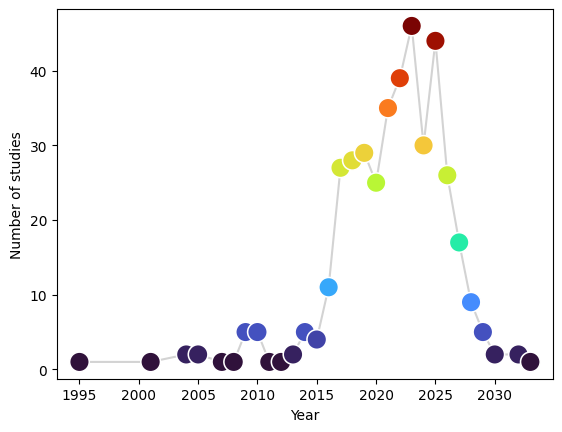

In [22]:
# Build a line plot showing distribution of retinoids research

# Suppress seaborn version mismatch warings
import warnings
warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning
)

# Build a plot
data = df_ct_retinoids_copy['completion_date'].dropna().value_counts().sort_index().reset_index()
data.columns = ['Year', 'Count']
ax = sns.lineplot(data=data, x='Year', y='Count', color='lightgrey', zorder=1)
sns.scatterplot(data=data, x='Year', y='Count', hue='Count', palette='turbo', 
                s=200, legend=False, zorder=2)
ax.set_xlabel('Year')
ax.set_ylabel('Number of studies');

As the plot demonstrates, the interest for studiying various forms of retinoids has grown over the years and saw it's peak around year 2015 and continues that way to this date. As there are some studies in the dataset that are ongoing and have a completion date in the future, the plot may not reflect the interest growth in the future adequately at this time.

One drawback to this is that ClinicalTrials.gov was built after the first topical retinol was approved by FDA in the early 70s.

For more research, scraping such sources as PubMed or Drugs@FDA could potentially provde more insights in the way retinoids were studied and approved historically.


As seen earlier, there are many different forms (and generations) of retinoids. And over time the studies must have shifted to new, more advanced types of retinoids. The next plot will help visualize that process

In [23]:
df_ct_retinoids_copy['matched_retinoid'].unique()

array(['isotretinoin', 'retinoid', 'retinoic acid', 'tretinoin',
       'retinol', 'alitretinoin', 'vitamin a', 'retin-a', 'adapalene',
       'retinyl palmitate', 'atralin', 'acitretin', 'bexarotene',
       'i̇sotretinoin', 'altreno', 'retinal', 'tazarotene', 'fenretinide',
       'tazorac', 'bakuchiol', 'ziana', 'palovarotene', 'avita',
       'duobrii', 'targretin', 'trifarotene', 'panretin', 'renova',
       'differin'], dtype=object)

In [24]:
# Fix uncommon character for isotretionoin so it represents the same group of retinoids
df_ct_retinoids_copy['matched_retinoid'] = (
    df_ct_retinoids_copy['matched_retinoid']
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)
df_ct_retinoids_copy['matched_retinoid'].unique()

array(['isotretinoin', 'retinoid', 'retinoic acid', 'tretinoin',
       'retinol', 'alitretinoin', 'vitamin a', 'retin-a', 'adapalene',
       'retinyl palmitate', 'atralin', 'acitretin', 'bexarotene',
       'altreno', 'retinal', 'tazarotene', 'fenretinide', 'tazorac',
       'bakuchiol', 'ziana', 'palovarotene', 'avita', 'duobrii',
       'targretin', 'trifarotene', 'panretin', 'renova', 'differin'],
      dtype=object)

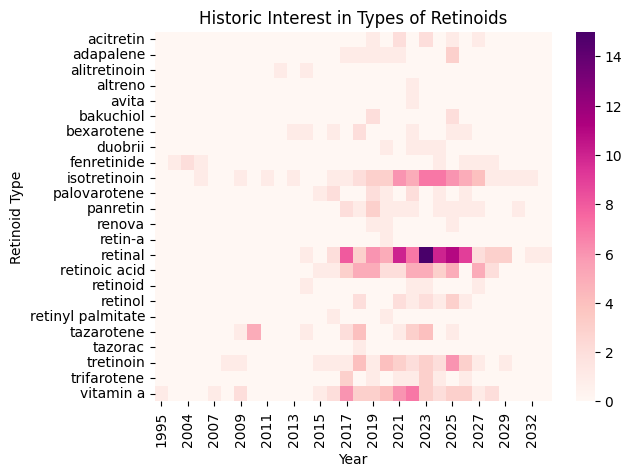

In [25]:
# Build a plot showing distribution of retinoid research by type of retinoid each year
plot_data = df_ct_retinoids_copy.groupby(['completion_date', 'matched_retinoid']).size().reset_index(name='count')
heatmap_data = plot_data.pivot(index='matched_retinoid', columns='completion_date', values='count').fillna(0)
sns.heatmap(heatmap_data, cmap='RdPu')
plt.xlabel('Year')
plt.ylabel('Retinoid Type')
plt.title('Historic Interest in Types of Retinoids');

Looks like the highest interest was attributed to `retinal`, followed by `isotretinoin`, `vitamin a` and `retinoic acid`.

As seen earlier from a brief dataset overview, the conditions that are treated by retionoids are numerous, and not limited to traditional anti-ageing or acne treating.

To get a better understanding of how retinoids are used, building a `word cloud` could be a good demonstration.

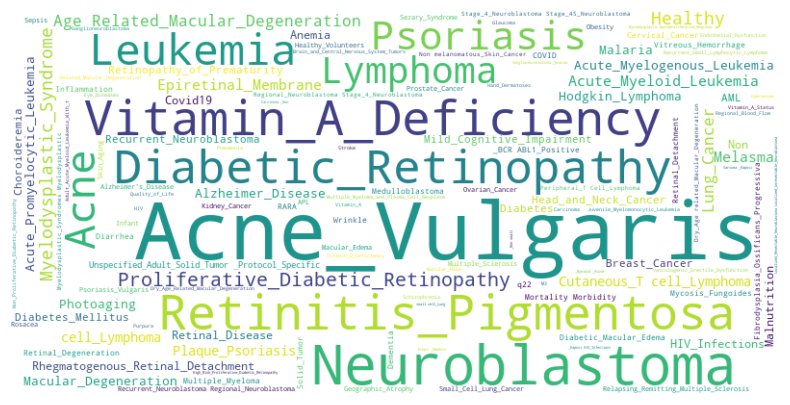

In [26]:
# Build Word Cloud showing many conditions treated with retinoids

conditions = ', '.join(df_ct_retinoids_copy['conditions'].str.split('|').explode().str.strip().str.replace(r'\s+', '_', regex=True))
retinoid_cloud= WordCloud(width=800, height=400, background_color='white').generate(conditions)
plt.figure(figsize=(10, 5))
plt.imshow(retinoid_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

As the plot above shows, the use of retinoids goes far beyond cosmetic purposes. However, our second dataset is all about it. Sephora does not sell any prescription retinoids, but the interest to this miracle ingredient family is growing by the day.

One idea for further research could be to add data of similar kind pulled from places that sell prescription drugs (like GoodRx API).

In order to perform a meaningful merge of the two datasets, some tweaks will have to be made.

For example, aggregating some variables of interest (like `product price` or `enrollment`) by the type or retinoid and finding their mean/sum could be one way.

In [27]:
# Prepare the `df_ct_retinoids_copy` for merging
df_ct_retinoids_copy.head()

,matched_retinoid,study_status,study_results,conditions,sex,age,enrollment,funder_type,study_type,study_design,completion_date
1,isotretinoin,COMPLETED,NO,Adult Solid Neoplasm,ALL,"ADULT, OLDER_ADULT",51.0,NIH,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,2018
2,retinoid,COMPLETED,NO,Thyroid Cancer,ALL,"ADULT, OLDER_ADULT",25.0,OTHER,OBSERVATIONAL,Observational Model: CASE_CONTROL | Time Persp...,2014
3,retinoic acid,COMPLETED,YES,Neuroblastoma,ALL,"CHILD, ADULT",20.0,INDUSTRY,INTERVENTIONAL,Allocation: RANDOMIZED | Intervention Model: C...,2019
4,isotretinoin,COMPLETED,NO,Localized Unresectable Neuroblastoma|Recurrent...,ALL,"CHILD, ADULT",29.0,NIH,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,<NA>
5,isotretinoin,ACTIVE_NOT_RECRUITING,NO,Recurrent Neuroblastoma|Refractory Neuroblastoma,ALL,"CHILD, ADULT",27.0,NIH,INTERVENTIONAL,Allocation: NA | Intervention Model: SINGLE_GR...,2027


In [28]:
# Check value categories in the columns of interest
df_ct_retinoids_copy['study_status'].unique()

array(['COMPLETED', 'ACTIVE_NOT_RECRUITING', 'TERMINATED', 'UNKNOWN',
       'NOT_YET_RECRUITING', 'RECRUITING', 'WITHDRAWN',
       'ENROLLING_BY_INVITATION', 'SUSPENDED', 'NO_LONGER_AVAILABLE'],
      dtype=object)

In [29]:
df_ct_retinoids_copy['age'].unique()

array(['ADULT, OLDER_ADULT', 'CHILD, ADULT', 'CHILD, ADULT, OLDER_ADULT',
       'ADULT', 'CHILD', 'OLDER_ADULT'], dtype=object)

In [30]:
df_ct_retinoids_copy['funder_type'].unique()

array(['NIH', 'OTHER', 'INDUSTRY', 'NETWORK', 'OTHER_GOV', 'INDIV', 'FED'],
      dtype=object)

In [31]:
df_ct_retinoids_copy['study_type'].unique()

array(['INTERVENTIONAL', 'OBSERVATIONAL', 'EXPANDED_ACCESS'], dtype=object)

In [32]:
df_ct_retinoids_copy['sex'].unique()

array(['ALL', 'MALE', 'FEMALE'], dtype=object)

In [33]:
# Aggregate variables from `df_ct_retinoids_copy` by retinoid type
df_ct_sephora_ready = df_ct_retinoids_copy.groupby('matched_retinoid').agg(
    # Split study_status, age, funder_type, study_type and gender
    completed=('study_status', lambda x: (x == 'COMPLETED').sum()),
    other_status=('study_status', lambda x: (x != 'COMPLETED').sum()),

    adult=('age', lambda x: x.str.contains('ADULT|OLDER_ADULT', na=False).sum()),
    child=('age', lambda x: x.str.contains('CHILD', na=False).sum()),

    total_enrollment=('enrollment', 'sum'),

    government=('funder_type', lambda x: x.isin(['FED', 'OTHER_GOV', 'NIH']).sum()),
    industry=('funder_type', lambda x: (x == 'INDUSTRY').sum()),
    non_profit=('funder_type', lambda x: x.isin(['OTHER', 'INDIV', 'NETWORK']).sum()),

    interventional=('study_type', lambda x: (x == 'INTERVENTIONAL').sum()),
    observational=('study_type', lambda x: (x == 'OBSERVATIONAL').sum()),
    pre_approval=('study_type', lambda x: (x == 'EXPANDED_ACCESS').sum()),

    male=('sex', lambda x: x.isin(['MALE', 'ALL']).sum()),
    female=('sex', lambda x: x.isin(['FEMALE', 'ALL']).sum()),
).reset_index()
df_ct_sephora_ready.head(28)

,matched_retinoid,completed,other_status,adult,child,total_enrollment,government,industry,non_profit,interventional,observational,pre_approval,male,female
0,acitretin,15,17,32,2,2589.0,2,3,27,30,2,0,31,31
1,adapalene,21,9,30,14,7965.0,0,19,11,30,0,0,27,30
2,alitretinoin,9,5,14,0,2644.0,0,8,6,14,0,0,14,14
3,altreno,1,0,1,0,25.0,0,0,1,1,0,0,1,1
4,atralin,2,1,3,0,168.0,0,2,1,3,0,0,3,3
5,avita,1,0,1,0,99.0,0,0,1,0,1,0,1,1
6,bakuchiol,3,1,4,0,150.0,0,1,3,4,0,0,2,4
7,bexarotene,27,13,40,2,2510.0,4,10,26,40,0,0,37,40
8,differin,4,0,4,2,371.0,0,3,1,4,0,0,3,3
9,duobrii,2,2,4,0,83.0,0,0,4,4,0,0,4,4


It is a common thing that a lot of research is sponsored by cosmetic and pharaceutical companies, sometimes it may cause concerns regarding full independance of such studies. 

It may be insightful to take a look at a chart showing the distribution of retinoids research by the type of sponsor: `government`, `non-profit` or `industry`. 

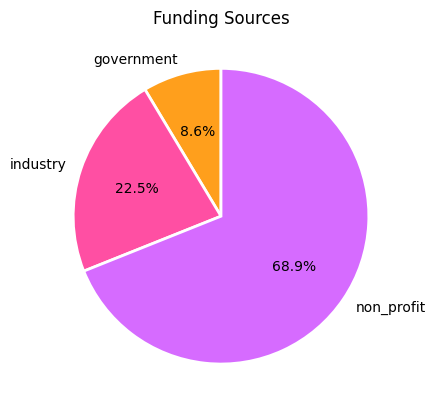

In [34]:
# Build a pie-chart for funding distribution

funding_sum = df_ct_sephora_ready[['government', 'industry', 'non_profit']].sum()
plt.pie(
    funding_sum,
    labels=funding_sum.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9f1c', '#ff4fa3', '#d66bff'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
plt.title('Funding Sources');

Even though a large chunk of the plot belongs to the category of `non-profit`, it actually includes many sources of funding, such as `individual`, `network` or `other`, making it a kind of `aggregate` group. Apart from that, we can tell that industry puts a lot of money into research of retionoids, while government funding is very limited.

### 2.3 Assess Dataset 2 - Sephora Products and Skincare Reviews

[back](#2.-Assess-data-and-Clean-data)

[→](#2.4-Clean-and-Analyse-Dataset-2---Sephora-Products-and-Skincare-Reviews)

In [35]:
# Prepare the `df_kaggle_retinoids` for merging
df_kaggle_retinoids_copy = df_kaggle_retinoids.copy()
df_kaggle_retinoids_copy.head()

,matched_retinoid,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
94,retinyl palmitate,P384537,GENIUS Ultimate Anti-Aging Cream,6018,Algenist,19733,4.2525,503.0,2 oz/ 60 mL,Size,2 oz/ 60 mL,NaN,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",112.0,NaN,NaN,0,0,0,0,0,"['Vegan', 'Collagen', 'Hypoallergenic', 'Good ...",Skincare,Moisturizers,Moisturizers,1,75.0,75.0
95,retinyl palmitate,P388200,GENIUS Ultimate Anti-Aging Melting Cleanser,6018,Algenist,9314,4.0569,334.0,5 oz/ 150 mL,Size,5 oz/ 150 mL,NaN,"['C12-15 Alkyl Benzoate, Ethylhexyl Palmitate,...",38.0,NaN,NaN,0,0,0,1,0,NaN,Skincare,Cleansers,Face Wash & Cleansers,0,NaN,NaN
97,retinyl palmitate,P500716,10 Day Results Kit,6018,Algenist,3206,4.8023,258.0,NaN,NaN,NaN,NaN,"['GENIUS Liquid Collagen:', 'Collagen (Vegan),...",88.0,142.0,NaN,0,0,0,0,1,"['Vegan', 'Good for: Loss of firmness', 'Good ...",Skincare,Value & Gift Sets,NaN,0,NaN,NaN
98,retinyl palmitate,P379907,Advanced Anti-Aging Repairing Oil,6018,Algenist,10676,4.4531,245.0,1 oz/ 30 mL,Size,1 oz/ 30 mL,NaN,"['Chlorella Protothecoides Oil, Cetearyl Ethyl...",82.0,NaN,NaN,0,0,0,0,0,NaN,Skincare,Moisturizers,Face Oils,0,NaN,NaN
102,bakuchiol,P474809,Blue Algae Vitamin C Skinclarity Brightening S...,6018,Algenist,6040,4.6087,207.0,1 oz/ 30 mL,Size,1 oz/ 30 mL,NaN,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",72.0,NaN,NaN,0,0,0,0,1,NaN,Skincare,Treatments,Face Serums,0,NaN,NaN


In [36]:
df_kaggle_retinoids_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 326 entries, 94 to 8424
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   matched_retinoid    326 non-null    object 
 1   product_id          326 non-null    object 
 2   product_name        326 non-null    object 
 3   brand_id            326 non-null    int64  
 4   brand_name          326 non-null    object 
 5   loves_count         326 non-null    int64  
 6   rating              319 non-null    float64
 7   reviews             319 non-null    float64
 8   size                271 non-null    object 
 9   variation_type      262 non-null    object 
 10  variation_value     256 non-null    object 
 11  variation_desc      24 non-null     object 
 12  ingredients         326 non-null    object 
 13  price_usd           326 non-null    float64
 14  value_price_usd     39 non-null     float64
 15  sale_price_usd      6 non-null      float64
 16  limited_edi

In [37]:
# Check types of values for product size to develop a strategy for extracting the volume values
df_kaggle_retinoids_copy['size'].unique()

array(['2 oz/ 60 mL', '5 oz/ 150 mL', nan, '1 oz/ 30 mL',
       '0.85 oz/ 25 mL', '1.69 oz/ 50 mL', '1.7 oz/ 50 mL',
       '0.5 oz/ 14 mL', '3.9 oz / 115 mL', '.5 oz/ 15 mL',
       '8.5 oz/ 250 mL', '4.2 oz/ 125 mL', '5.7 oz/ 169 mL',
       '12 x 0.05oz/1.4g', '0.5 oz/ 15 mL', '0.08 oz / 2.5 g',
       '1 oz / 30 mL', '8 oz/ 250 mL', '0.15 oz/ 4.44 mL',
       '0.14 oz/ 4.45 mL', '0.26 oz/ 7.9 mL', '1.6 oz/ 50 mL',
       '3.4 oz/ 100 mL', '.25 oz', '1.7 oz / 50 mL', '0.5 oz / 15 mL',
       '2.5 oz/ 75 mL', '0.5 oz/ 15 g', '1.7 oz/ 50 g',
       '30 Treatments + 5 Bonus', '5 Treatments', '8 Textured Towels',
       '16 Treatments', '2 Textured Towels', '4 oz/ 120 mL',
       '1.5 oz/ 45 mL', '.75 oz / 22 mL', '0.33 oz/ 10 mL',
       '0.30 oz/ 9 mL', '1.0 oz/ 30 mL', '1 / 30', '0.25 oz/ 7.5 mL',
       '0.27 oz/ 8 mL - Travel Size', '0.14 oz/ 4.2mL',
       '30 Vegan Capsules / 30 Vegan Softgels', '90 capsules',
       '2.53 oz / 75 mL', '6.76 oz/ 200 mL', '0.31 oz/ 9 g', '0.37 oz

#### Quality and  Tidiness issues identified for Dataset 2 -  Sephora Products and Skincare Reviews

- `df_kaggle_retinoids_copy` has a number of missing (NaN) values (quality).
- `ingredients` and `highlights` columns contain lists in single cell (tidiness).
- `size` column has inconsistent format and includes indication of amount (`oz`, `ml` and separation `/`) or alternative description (quality).

### 2.4 Clean and Analyse Dataset 2 - Sephora Products and Skincare Reviews

[back](#2.-Assess-data-and-Clean-data)

[→](#2.5-Combine-datasets)

In [38]:
# Create `size_oz` column that contains only numeric values for ounces
df_kaggle_retinoids_copy.insert(
    loc=9, 
    column='size_oz', 
    value=df_kaggle_retinoids_copy['size'].str.extract(r'(\d*\.?\d+)\s*oz').astype(float)
)

In [39]:
df_kaggle_retinoids_copy.sample(50)

,matched_retinoid,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,size_oz,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
5657,retinyl palmitate,P469195,Supershine Moisturizing Hair Cream,6346,Oribe,20865,4.4692,422.0,5 oz/ 150 mL,5.00,Size,5 oz/ 150 mL,NaN,"['Aqua/Water/Eau, Dimethicone, Cyclopentasilox...",52.0,NaN,NaN,0,0,1,0,0,"['Good for: Dryness', 'Good for: Frizz', 'Hydr...",Hair,Hair Styling & Treatments,Hair Styling Products,1,19.5,19.5
3943,bakuchiol,P404232,DermalQuench +Retinol Advanced Resurfacing Tre...,5946,Kate Somerville,8412,4.0541,74.0,2.5 oz,2.50,Size,2.5 oz,NaN,"['Aqua/Water/Eau, Isobutane, Propane, Perfluor...",110.0,NaN,NaN,0,0,0,0,0,NaN,Skincare,Treatments,Face Serums,0,NaN,NaN
6041,retinyl acetate,P428250,Oil-Absorbing Pore Treatment Strips,6209,Peace Out,102327,3.9750,1562.0,NaN,NaN,NaN,NaN,NaN,"['DMAE Bitartrate, Retinyl Acetate (Vitamin A)...",19.0,NaN,NaN,0,0,0,0,0,"['Best for Oily Skin', 'Good for: Pores', 'Cle...",Skincare,Treatments,Blemish & Acne Treatments,0,NaN,NaN
7150,retinal,P474122,Advanced Retinol Nightly Renewal Face Moisturi...,6358,StriVectin,4940,4.7813,64.0,1.7 oz/ 50 mL,1.70,Size,1.7 oz/ 50 mL,NaN,"['Water/Aqua/Eau, Trimethylolpropane Tricapryl...",119.0,NaN,NaN,0,0,1,0,0,"['Good for: Dullness/Uneven Texture', 'Good fo...",Skincare,Moisturizers,Moisturizers,0,NaN,NaN
6823,retinol,P173619,Benefiance WrinkleResist24 Pure Retinol Expres...,5337,Shiseido,81341,4.4220,500.0,12 Packettes x 2 Sheets,NaN,Size,12 Packettes x 2 Sheets,NaN,"['Water, Butylene Glycol, Pentaerythrityl Tetr...",70.0,NaN,NaN,0,0,0,0,0,"['allure 2020 Best of Beauty Award Winner', 'G...",Skincare,Eye Care,Eye Masks,1,20.0,20.0
1860,hydroxypinacolone retinoate,P503814,Dynamic Skin Retinol Serum,6219,Dermalogica,3898,4.8081,344.0,1 oz / 30 mL,1.00,Size,1 oz / 30 mL,NaN,"['Water/Aqua/Eau, Squalane, Glycerin, Hexyldec...",92.0,NaN,NaN,0,0,0,0,0,"['Vegan', 'Good for: Dullness/Uneven Texture',...",Skincare,Treatments,Face Serums,0,NaN,NaN
5711,retinyl palmitate,P469179,Signature Moisture Hair Mask,6346,Oribe,4416,4.2667,15.0,5.9 oz/ 175 mL,5.90,Size,5.9 oz/ 175 mL,NaN,"['Aqua/Water/Eau, Cetearyl Alcohol, Dimethicon...",66.0,NaN,NaN,0,0,1,0,0,"['Vegan', 'Hydrating', 'All Hair Types', 'Good...",Hair,Hair Styling & Treatments,Hair Masks,0,NaN,NaN
7056,retinyl palmitate,P504170,On-Set Essentials: Primer + Setting Spray Trio...,3990,Smashbox,803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['Photo Finish Endurance Breathable Setting Sp...,34.0,59.0,NaN,1,0,1,0,0,"['Vegan', 'Good for: Pores', 'Long-wearing', '...",Makeup,Face,Face Primer,0,NaN,NaN
5602,bakuchiol,P434546,Goodnight Glow Bakuchiol Sleeping Crème,5674,OLEHENRIKSEN,55708,3.8817,524.0,1.7 oz/ 50 mL,1.70,Size,1.7 oz/ 50 mL,NaN,"['Water, Glycerin, Vitis Vinifera (Grape) Seed...",60.0,NaN,NaN,0,0,0,0,1,"['Vegan', 'Good for: Dullness/Uneven Texture',...",Skincare,Moisturizers,Night Creams,0,NaN,NaN
987,retinyl palmitate,P174213,Full-On Plumping Lip Polish Gloss,5984,Buxom,464024,4.6250,12367.0,0.15 oz/ 4.44 mL,0.15,Color,White Russian,nude pink,['All original shades except Dominique and Kry...,25.0,NaN,NaN,0,0,0,0,0,"['Metallic Finish', 'Plumping', 'Without Phtha...",Makeup,Lip,Lip Gloss,5,25.0,25.0


In [40]:
# Drop some columns from `df_kaggle_retinoids_copy` that do not pose interest for further research
df_kaggle_retinoids_copy.drop(columns=['product_id', 'brand_id', 'variation_type', 'variation_value', 'variation_desc', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'child_count', 'child_max_price', 'child_min_price'], inplace=True)
df_kaggle_retinoids_copy.head()

,matched_retinoid,product_name,brand_name,loves_count,rating,reviews,size,size_oz,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category
94,retinyl palmitate,GENIUS Ultimate Anti-Aging Cream,Algenist,19733,4.2525,503.0,2 oz/ 60 mL,2.0,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",112.0,"['Vegan', 'Collagen', 'Hypoallergenic', 'Good ...",Skincare,Moisturizers,Moisturizers
95,retinyl palmitate,GENIUS Ultimate Anti-Aging Melting Cleanser,Algenist,9314,4.0569,334.0,5 oz/ 150 mL,5.0,"['C12-15 Alkyl Benzoate, Ethylhexyl Palmitate,...",38.0,NaN,Skincare,Cleansers,Face Wash & Cleansers
97,retinyl palmitate,10 Day Results Kit,Algenist,3206,4.8023,258.0,NaN,NaN,"['GENIUS Liquid Collagen:', 'Collagen (Vegan),...",88.0,"['Vegan', 'Good for: Loss of firmness', 'Good ...",Skincare,Value & Gift Sets,NaN
98,retinyl palmitate,Advanced Anti-Aging Repairing Oil,Algenist,10676,4.4531,245.0,1 oz/ 30 mL,1.0,"['Chlorella Protothecoides Oil, Cetearyl Ethyl...",82.0,NaN,Skincare,Moisturizers,Face Oils
102,bakuchiol,Blue Algae Vitamin C Skinclarity Brightening S...,Algenist,6040,4.6087,207.0,1 oz/ 30 mL,1.0,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",72.0,NaN,Skincare,Treatments,Face Serums


In [41]:
# Calculate price per ounce for each product
df_kaggle_retinoids_copy['price_per_oz'] = df_kaggle_retinoids_copy['price_usd']/df_kaggle_retinoids_copy['size_oz']
df_kaggle_retinoids_copy.head(20)

,matched_retinoid,product_name,brand_name,loves_count,rating,reviews,size,size_oz,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_per_oz
94,retinyl palmitate,GENIUS Ultimate Anti-Aging Cream,Algenist,19733,4.2525,503.0,2 oz/ 60 mL,2.00,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",112.0,"['Vegan', 'Collagen', 'Hypoallergenic', 'Good ...",Skincare,Moisturizers,Moisturizers,56.000000
95,retinyl palmitate,GENIUS Ultimate Anti-Aging Melting Cleanser,Algenist,9314,4.0569,334.0,5 oz/ 150 mL,5.00,"['C12-15 Alkyl Benzoate, Ethylhexyl Palmitate,...",38.0,NaN,Skincare,Cleansers,Face Wash & Cleansers,7.600000
97,retinyl palmitate,10 Day Results Kit,Algenist,3206,4.8023,258.0,NaN,NaN,"['GENIUS Liquid Collagen:', 'Collagen (Vegan),...",88.0,"['Vegan', 'Good for: Loss of firmness', 'Good ...",Skincare,Value & Gift Sets,NaN,NaN
98,retinyl palmitate,Advanced Anti-Aging Repairing Oil,Algenist,10676,4.4531,245.0,1 oz/ 30 mL,1.00,"['Chlorella Protothecoides Oil, Cetearyl Ethyl...",82.0,NaN,Skincare,Moisturizers,Face Oils,82.000000
102,bakuchiol,Blue Algae Vitamin C Skinclarity Brightening S...,Algenist,6040,4.6087,207.0,1 oz/ 30 mL,1.00,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",72.0,NaN,Skincare,Treatments,Face Serums,72.000000
110,retinyl palmitate,AA (Alguronic Acid) Barrier Serum,Algenist,3877,3.9700,100.0,1 oz/ 30 mL,1.00,"['Water (Aqua, Eau), Butylene Glycol, PEG-8 Di...",85.0,"['Vegan', 'Niacinamide', 'Hypoallergenic', 'Go...",Skincare,Treatments,Face Serums,85.000000
114,retinol,ELEVATE Advanced Retinol Serum,Algenist,5451,4.1026,39.0,1 oz/ 30 mL,1.00,"['Water (Aqua, Eau), Dimethicone, Glycerin, Bu...",98.0,"['Vegan', 'Retinol', 'Hypoallergenic', 'Good f...",Skincare,Treatments,Face Serums,98.000000
123,retinol,Vitamin A Serum with 0.5% Retinol,Alpha-H,7074,4.3579,95.0,0.85 oz/ 25 mL,0.85,"['Aqua (Water), Glycerin, Methyl Gluceth-20, P...",65.0,"['Vegan', 'Good for: Dullness/Uneven Texture',...",Skincare,Treatments,Face Serums,76.470588
128,hydroxypinacolone retinoate,Liquid Gold Midnight Reboot Serum with 14% Gly...,Alpha-H,3928,5.0000,16.0,1.69 oz/ 50 mL,1.69,"['Aqua (Water), Glycolic Acid, Glycerin, Butyl...",105.0,"['Good for: Dullness/Uneven Texture', 'Good fo...",Skincare,Treatments,Face Serums,62.130178
129,retinol,Beauty Sleep Power Peel Age-Defying Night Peel,Alpha-H,6057,4.6000,15.0,1.69 oz/ 50 mL,1.69,"['10% Glycolic Acid, 0.5% Retinol, Panthenol (...",106.0,"['Good for: Dullness/Uneven Texture', 'Clean a...",Skincare,Treatments,Facial Peels,62.721893


In [42]:
df_kaggle_retinoids_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 326 entries, 94 to 8424
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   matched_retinoid    326 non-null    object 
 1   product_name        326 non-null    object 
 2   brand_name          326 non-null    object 
 3   loves_count         326 non-null    int64  
 4   rating              319 non-null    float64
 5   reviews             319 non-null    float64
 6   size                271 non-null    object 
 7   size_oz             243 non-null    float64
 8   ingredients         326 non-null    object 
 9   price_usd           326 non-null    float64
 10  highlights          245 non-null    object 
 11  primary_category    326 non-null    object 
 12  secondary_category  326 non-null    object 
 13  tertiary_category   267 non-null    object 
 14  price_per_oz        243 non-null    float64
dtypes: float64(5), int64(1), object(9)
memory usage: 40.8+ KB


As discussed earlier, some of the calculated values for the new column of `price_per_oz` are going to be NaN, as some of the products containing some sort of retionoid were supplied in the form of a set or had irrelevant description, which prevented the calculation. However, for the purposes of continued research, when building the following box plot, any NaN values will be ignored and would not disrupt the process.

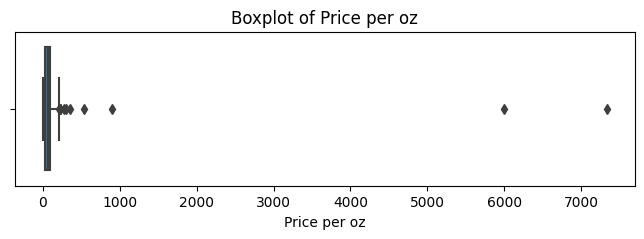

In [43]:
# Build a box plot to spot any outliers in price per ounce
plt.figure(figsize=(8, 2))
sns.boxplot(x=df_kaggle_retinoids_copy['price_per_oz'])
plt.xlabel('Price per oz')
plt.title('Boxplot of Price per oz');

Looks like there are some outliers in retinol containing products regarding their price. This is likely due to search for retinoids catching on some irrelevant items.

Checking for 50 highest priced per oz products may help with locating those items.

In [44]:
# Check top 50 priced per ounce retinoids
df_kaggle_retinoids_copy.nlargest(50, 'price_per_oz')

,matched_retinoid,product_name,brand_name,loves_count,rating,reviews,size,size_oz,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_per_oz
7400,retinyl palmitate,Amazonian Clay Waterproof Brow Pencil,tarte,20532,4.3535,874.0,0.003 oz/ 0.085 g,0.0030,"['Cyclopentasiloxane, Polyglyceryl-4 Isosteara...",22.0,NaN,Makeup,Eye,Eyebrow,7333.333333
3620,retinyl acetate,Mini Brow Power Universal Brow Pencil,IT Cosmetics,5168,4.1481,27.0,0.0025 oz/ 0.07 g,0.0025,"['Hydrogenated Coco-Glycerides, Ceresin, Cande...",15.0,"['Waterproof', 'Long-wearing']",Mini Size,Makeup,NaN,6000.000000
401,ziana,Supreme Nudes Pressed Pigment Eyeshadow Palette,Artist Couture,21383,4.4454,119.0,12 x 0.05oz/1.4g,0.0500,"['Exposed:', 'Mica, Talc, Boron Nitride, Zinc ...",45.0,"['Vegan', 'Pressed Powder Formula', 'Long-wear...",Makeup,Eye,Eye Palettes,900.000000
6106,retinyl palmitate,Lashes to Die For Turbo Conditioning Lash Enha...,Peter Thomas Roth,4594,3.7254,284.0,.16 oz/ 4.7 mL,0.1600,"['Water/Aqua/Eau, Glycerin, Propylene Glycol, ...",85.0,NaN,Makeup,Eye,Eyebrow,531.250000
7355,retinyl palmitate,Amazonian Clay Waterproof 12-Hour Concealer,tarte,79657,4.0378,1587.0,0.07 oz/ 2 g,0.0700,"['All shades contain:', 'Squalane, Polyethylen...",25.0,NaN,Makeup,Face,Concealer,357.142857
2213,retinol,Retinol + Bakuchiol Serum 2.5x,Dr. Lara Devgan Scientific Beauty,581,3.0000,1.0,1 oz/ 30 mL,1.0000,"['Isopentyldiol, Dimethyl Isosorbide, Polysorb...",300.0,"['Good for: Anti-Aging', 'Good for: Dark spots...",Skincare,Treatments,Face Serums,300.000000
3944,retinyl palmitate,Line Release Under Eye Repair Cream,Kate Somerville,4556,3.9143,70.0,0.5 oz,0.5000,"['Water, Phenyl Trimethicone, Cyclopentasiloxa...",140.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,280.000000
539,retinyl palmitate,Dandelion Baby-Pink Blush,Benefit Cosmetics,83967,4.4718,1933.0,0.08 oz / 2.5 g,0.0800,"['Talc, Mica, Calcium Aluminum Borosilicate, P...",18.0,"['Pressed Powder Formula', 'Satin Finish', 'Lo...",Makeup,Cheek,Blush,225.000000
557,retinyl palmitate,Mini Dandelion Baby-Pink Blush,Benefit Cosmetics,26463,4.4200,100.0,0.08 oz / 2.5 g,0.0800,"['Talc, Mica, Calcium Aluminum Borosilicate, P...",18.0,"['Pressed Powder Formula', 'Satin Finish', 'Lo...",Mini Size,Makeup,NaN,225.000000
7897,retinyl palmitate,Cheek Popper Blushing Highlighter,Too Faced,6562,3.6667,9.0,0.12 oz / 3.4g,0.1200,"['Synthetic Fluorphlogopite , Alumina, Hydroge...",27.0,"['Radiant Finish', 'Pressed Powder Formula', '...",Makeup,Face,Highlighter,225.000000


As inspection showed, some prices look unrealistically high as the ingredient exists in some very small items, like a brow pencil or a trial size. Ultimately these kinds of retinol-containing items are very unlikely to affect the buyers choice because of a retinoid in their ingredients list. Additionally, it looks like a lot of the products  contain a type of `Retinyl Esters` which are considered the mildest form of retinol. Another "hiccup" was because an eyeshadow palette somehow has a prescription retinol brand name present in their ingredients list, which is clearly a mistake.

Removing the rows that could skew the results due to the mentioned factors may improve further research and visualizatoins.

In [45]:
# Remove irrelevant rows by index
df_kaggle_retinoids_copy.drop(index=[7400, 3620, 401, 6106, 7355, 539, 557, 7897, 988, 7861, 5253, 4470], inplace=True)
df_kaggle_retinoids_copy.nlargest(50, 'price_per_oz')

,matched_retinoid,product_name,brand_name,loves_count,rating,reviews,size,size_oz,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_per_oz
2213,retinol,Retinol + Bakuchiol Serum 2.5x,Dr. Lara Devgan Scientific Beauty,581,3.0000,1.0,1 oz/ 30 mL,1.00,"['Isopentyldiol, Dimethyl Isosorbide, Polysorb...",300.0,"['Good for: Anti-Aging', 'Good for: Dark spots...",Skincare,Treatments,Face Serums,300.000000
3944,retinyl palmitate,Line Release Under Eye Repair Cream,Kate Somerville,4556,3.9143,70.0,0.5 oz,0.50,"['Water, Phenyl Trimethicone, Cyclopentasiloxa...",140.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,280.000000
3264,retinyl palmitate,N° 28 Lip Treatment Oil,Hourglass,38471,3.8546,399.0,0.25 oz/ 7.5 mL,0.25,"['Oleic/Linoleic/Linolenic Polyglycerides, Hyd...",54.0,NaN,Makeup,Lip,Lip Balm & Treatment,216.000000
8388,bakuchiol,Lift & Contour 1% Bakuchiol & Peptide Eye Serum,Wishful,11916,4.0000,26.0,.21 oz / 6.2 mL,0.21,"['Water/Aqua/Eau, Glycerin, Propanediol, Hepty...",45.0,"['Vegan', 'Good for: Loss of firmness', 'Clean...",Skincare,Eye Care,Eye Creams & Treatments,214.285714
7189,retinol,Concentrated Ginseng Renewing Eye Cream,Sulwhasoo,3126,4.3333,3.0,0.67 oz / 20 mL,0.67,"['Water/Aqua/Eau, Squalane, Butylene Glycol, P...",140.0,"['Good for: Dullness/Uneven Texture', 'Good fo...",Skincare,Eye Care,Eye Creams & Treatments,208.955224
6042,retinol,Retinol Eye Stick,Peace Out,136726,4.2062,1329.0,0.14 oz / 4 g,0.14,"['Squalane, Synthetic Wax, Diisostearyl Malate...",28.0,"['Vegan', 'Good for: Loss of firmness', 'Good ...",Skincare,Eye Care,Eye Creams & Treatments,200.000000
3304,retinyl palmitate,N° 28 Lip Treatment Oil – At Night – Lunar New...,Hourglass,5401,2.3125,16.0,0.25 oz/ 7.5 mL,0.25,"['Oleic/Linoleic/Linolenic Polyglycerides, Hyd...",49.0,NaN,Makeup,Lip,Lip Balm & Treatment,196.000000
3927,retinol,Retinol Firming Eye Cream,Kate Somerville,17127,3.4462,130.0,0.5 oz/ 15 mL,0.50,"['Water, Dimethicone, Propanediol, Glycerin, P...",98.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,196.000000
422,retinyl palmitate,Mini The Cream with TFC8 Face Moisturizer,Augustinus Bader,6863,3.7647,17.0,0.5 oz/ 15 mL,0.50,"['Aqua (Water), Caprylic/Capric Triglyceride, ...",92.0,"['Good for: Dullness/Uneven Texture', 'Good fo...",Skincare,Mini Size,NaN,184.000000
415,retinyl palmitate,The Cream with TFC8 Face Moisturizer,Augustinus Bader,11428,4.3605,430.0,1 oz/ 30 mL,1.00,"['Aqua (Water), Caprylic/Capric Triglyceride, ...",180.0,"['Vitamin C', 'Good for: Anti-Aging', 'Good fo...",Skincare,Moisturizers,Moisturizers,180.000000


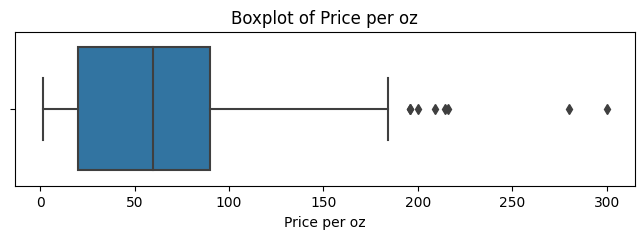

In [46]:
# Check how box plot looks this time
plt.figure(figsize=(8, 2))
sns.boxplot(x=df_kaggle_retinoids_copy['price_per_oz'])
plt.xlabel('Price per oz')
plt.title('Boxplot of Price per oz');

In [47]:
# Check minimum values for the price of retinoids
df_kaggle_retinoids_copy.describe()

,loves_count,rating,reviews,size_oz,price_usd,price_per_oz
count,314.000000,307.000000,307.000000,231.000000,314.000000,231.000000
mean,25576.799363,4.293769,446.462541,2.177403,59.064172,64.409553
std,51236.206049,0.492524,1111.074152,3.243167,40.958177,54.026843
min,0.000000,1.250000,1.000000,0.140000,11.700000,1.575758
25%,4567.500000,4.092650,37.000000,0.500000,30.500000,19.900990
50%,8392.000000,4.385100,151.000000,1.000000,52.000000,60.000000
75%,22533.250000,4.602800,409.500000,1.850000,72.000000,89.871795
max,464024.000000,5.000000,12367.000000,33.000000,340.000000,300.000000


Using `describe()` method reveiled that there are some really cheap retinoid containing products. Analysing the data from that standpoint may help understand these numbers.

In [48]:
# Check 50 lowest priced retinoids per oz
df_kaggle_retinoids_copy.nsmallest(50, 'price_per_oz')

,matched_retinoid,product_name,brand_name,loves_count,rating,reviews,size,size_oz,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_per_oz
3666,retinyl palmitate,Black Reserve Body & Hair Cleanser,Jack Black,1268,4.6000,10.0,33 oz/ 975 mL,33.00,"['Aqua (Water/Eau), Sodium C14-16 Olefin Sulfo...",52.00,NaN,Men,Other Needs,Body Products,1.575758
8143,bakuchiol,Glossy Shampoo,Verb,2325,4.2639,144.0,12 oz / 355 mL,12.00,"['Glycerin, Aqua/Water/Eau, Disodium Laureth S...",20.00,"['Good for: Dryness', 'Increases Shine']",Hair,Shampoo & Conditioner,Shampoo,1.666667
3662,retinyl palmitate,True Volume Thickening Shampoo,Jack Black,1813,4.0000,13.0,16 oz,16.00,"['Water, Sodium Methyl 2-Sulfolaurate, Cocamid...",32.00,NaN,Men,Hair,Shampoo & Conditioner,2.000000
3634,retinyl palmitate,Performance Remedy Turbo Wash Energizing Clea...,Jack Black,8831,4.6268,142.0,10 oz,10.00,"['Water, Sodium C14-16 Olefin Sulfonate, Cocam...",24.00,"['Without Parabens', 'Gluten Free', 'Cruelty-F...",Men,Other Needs,Body Products,2.400000
3642,retinyl palmitate,"All-Over Wash For Face, Hair & Body",Jack Black,6471,4.6645,152.0,10 oz,10.00,"['Water, Lauryl Glucoside, Sodium C14-16 Olefi...",24.00,"['Without Parabens', 'Alcohol Free', 'Gluten F...",Men,Skincare,Face Wash,2.400000
3672,retinyl palmitate,Black Reserve Body & Hair Cleanser,Jack Black,287,5.0000,2.0,10 oz / 296 mL,10.00,"['Aqua (Water/Eau), Sodium C14-16 Olefin Sulfo...",24.00,"['Vegan', 'Warm &Spicy Scent', 'Without Parabe...",Bath & Body,Bath & Shower,Body Wash & Shower Gel,2.400000
5066,retinyl palmitate,Hydrating Shampoo,Moroccanoil,46604,4.3145,1790.0,8.5 oz/ 250 mL,8.50,"['Aqua/Water/Eau, Sodium Lauroyl Sarcosinate, ...",26.00,NaN,Hair,Shampoo & Conditioner,Shampoo,3.058824
3669,retinyl palmitate,Oil-Control Toner,Jack Black,473,2.0000,4.0,8 oz/ 236 mL,8.00,['Water Hamamelis Virginiana (Witch Hazel/Hama...,25.00,NaN,Skincare,Cleansers,Toners,3.125000
3659,retinyl palmitate,Beard Wash,Jack Black,2813,4.8571,28.0,6 oz/ 177 mL,6.00,"['Water, Lauryl Glucoside, Sodium C14-16 Olefi...",19.00,NaN,Men,Shaving,Shaving,3.166667
874,retinyl palmitate,Prep,Bumble and bumble,15958,4.2313,294.0,8 oz/ 250 mL,8.00,"['Water\\Aqua\\Eau, Ascophyllum Nodosum (Algae...",28.00,"['Without Mineral Oil', 'Without Phthalates', ...",Hair,Hair Styling & Treatments,Hair Primers,3.500000


Checking the lowest price per oz demonstrates that it can happen when some large items like body cleanser or shampoo contain some retinoids.

Prior to merging the two datasets, it may be useful to take a look at some of the popular retionids used in cosmetic industry that do not have extensive research at `ClinicalTrials.gov`.

In [49]:
# Remove rows that contain retinoids present in `df_ct_retinoids_copy`
df_not_matched = df_kaggle_retinoids_copy[~df_kaggle_retinoids_copy['matched_retinoid'].isin(df_ct_retinoids_copy['matched_retinoid'])]
df_not_matched.head()

,matched_retinoid,product_name,brand_name,loves_count,rating,reviews,size,size_oz,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_per_oz
128,hydroxypinacolone retinoate,Liquid Gold Midnight Reboot Serum with 14% Gly...,Alpha-H,3928,5.0000,16.0,1.69 oz/ 50 mL,1.69,"['Aqua (Water), Glycolic Acid, Glycerin, Butyl...",105.0,"['Good for: Dullness/Uneven Texture', 'Good fo...",Skincare,Treatments,Face Serums,62.130178
478,hydroxypinacolone retinoate,The Nightly Retinol + Peptide Anti-Aging Serum,BeautyBio,5003,3.7000,10.0,1 oz/ 30 mL,1.00,"['Water, Ethylhexyl Palmitate, Glycerin, Peg-4...",95.0,"['Clean at Sephora', 'Retinol', 'Good for: Ant...",Skincare,Treatments,Face Serums,95.000000
1402,hydroxypinacolone retinoate,Smart Clinical Repair Wrinkle Correcting Serum,CLINIQUE,4293,4.1940,1670.0,1 oz/ 30 mL,1.00,"['Water\\Aqua\\Eau, Dimethicone, Isododecane, ...",71.0,"['Hyaluronic Acid', 'Good for: Anti-Aging', 'R...",Skincare,Treatments,Face Serums,71.000000
1860,hydroxypinacolone retinoate,Dynamic Skin Retinol Serum,Dermalogica,3898,4.8081,344.0,1 oz / 30 mL,1.00,"['Water/Aqua/Eau, Squalane, Glycerin, Hexyldec...",92.0,"['Vegan', 'Good for: Dullness/Uneven Texture',...",Skincare,Treatments,Face Serums,92.000000
1865,retinyl propionate,Retinol Acne Clearing Oil,Dermalogica,4762,4.3981,314.0,1 oz/ 30 mL,1.00,"['Coconut Alkanes, PPG-15 Stearyl Ether, Rosa ...",86.0,NaN,Skincare,Moisturizers,Face Oils,86.000000


In [50]:
# Combine some variables by retinoid type
df_not_matched_summary = df_not_matched.groupby('matched_retinoid').agg(
    mean_rating=('rating', 'mean'),
    total_reviews=('reviews', 'sum'),
    mean_price_per_oz=('price_per_oz', 'mean')
).reset_index()
df_not_matched_summary.head()

,matched_retinoid,mean_rating,total_reviews,mean_price_per_oz
0,hydroxypinacolone retinoate,4.363050,10392.0,71.380323
1,retinyl acetate,4.181656,7738.0,61.345968
2,retinyl propionate,4.516033,1341.0,90.125000


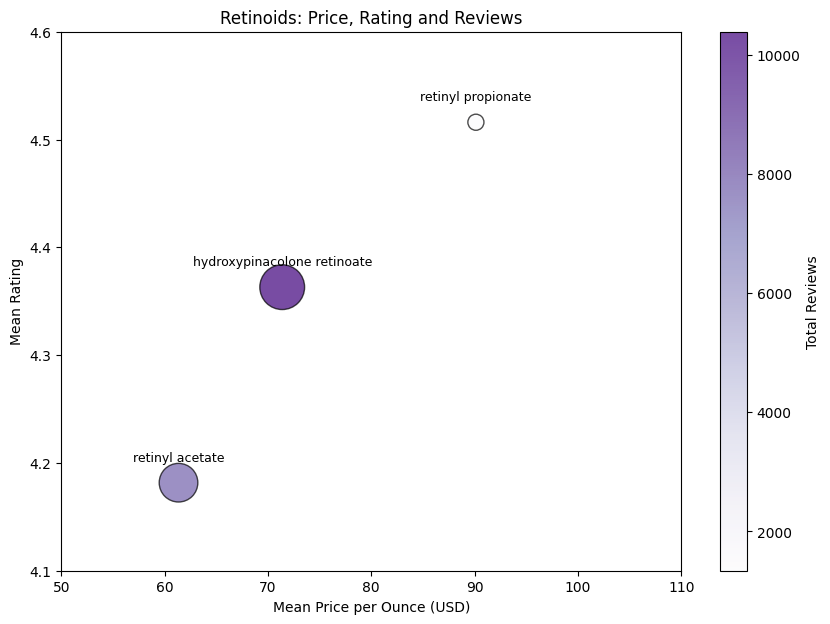

In [51]:
# Build a scatter plot showing the relationship between retinoid price, customer ratings and retinoid popularity
plt.figure(figsize=(10, 7))
plt.scatter(
    df_not_matched_summary['mean_price_per_oz'],
    df_not_matched_summary['mean_rating'],
    s=df_not_matched_summary['total_reviews'] / 10, 
    c=df_not_matched_summary['total_reviews'],
    cmap='Purples',
    alpha=0.7,
    edgecolors='black'
)
for _, row in df_not_matched_summary.iterrows():
    plt.text(
        row['mean_price_per_oz'],
        row['mean_rating'] + 0.02,
        row['matched_retinoid'],
        fontsize=9,
        ha='center'
    )
plt.xlabel('Mean Price per Ounce (USD)')
plt.ylabel('Mean Rating')
plt.title('Retinoids: Price, Rating and Reviews')
plt.colorbar(label='Total Reviews')

plt.xlim(50, 110) 
plt.ylim(4.1, 4.6);

The plot shows that the cheapest most reviewed retinoid in this subset is `retinyl acetate`. This is one of the mildest forms of Vitamin A, and a retinoid ester, likely explaining the lower price and driven by it amount of ratings. Another retinoid ester is `retinyl propionate`. However, the ratings in this case are the highest among the three retinoids along with the price. This could be explained by `retinyl propionate` [being](https://pubmed.ncbi.nlm.nih.gov/33098193/) a more advanced form of retinoid ester. But also, fewer reviews could make the outcome not as representative. At the same time [hydroxypinacolone retinoate](https://onlinelibrary.wiley.com/doi/full/10.1111/jocd.16621) has the largest number of reviews as well as boasts a pretty solid 4.4 rating. This is a so-called "next-generation" retinoid. One of the main claimed benefits of this type of retinoid is that it's behavior resembles that of a prescription retinoid, where skin needs [no extra steps](https://theskindiary.com/blogs/news/retinoid-pyramid-explained) to convert it into active form of retinoic acid.

### 2.5 Combine datasets

[back](#2.-Assess-data-and-Clean-data)

Merge the prepared `df_ct_retinoids_copy` and `df_kaggle_retinoids_copy` sets. Perform further analysis using the combined data.

In [52]:
# Merge the prepared `df_ct_sephora_ready` to `df_kaggle_retinoids_copy` by `matched_retinoid` column
df_retinoid_merged = df_kaggle_retinoids_copy.merge(
    df_ct_sephora_ready,
    on='matched_retinoid',
    how='left'
)
df_retinoid_merged.head(20)

,matched_retinoid,product_name,brand_name,loves_count,rating,reviews,size,size_oz,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_per_oz,completed,other_status,adult,child,total_enrollment,government,industry,non_profit,interventional,observational,pre_approval,male,female
0,retinyl palmitate,GENIUS Ultimate Anti-Aging Cream,Algenist,19733,4.2525,503.0,2 oz/ 60 mL,2.00,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",112.0,"['Vegan', 'Collagen', 'Hypoallergenic', 'Good ...",Skincare,Moisturizers,Moisturizers,56.000000,7.0,0.0,6.0,3.0,765.0,2.0,0.0,5.0,7.0,0.0,0.0,4.0,7.0
1,retinyl palmitate,GENIUS Ultimate Anti-Aging Melting Cleanser,Algenist,9314,4.0569,334.0,5 oz/ 150 mL,5.00,"['C12-15 Alkyl Benzoate, Ethylhexyl Palmitate,...",38.0,NaN,Skincare,Cleansers,Face Wash & Cleansers,7.600000,7.0,0.0,6.0,3.0,765.0,2.0,0.0,5.0,7.0,0.0,0.0,4.0,7.0
2,retinyl palmitate,10 Day Results Kit,Algenist,3206,4.8023,258.0,NaN,NaN,"['GENIUS Liquid Collagen:', 'Collagen (Vegan),...",88.0,"['Vegan', 'Good for: Loss of firmness', 'Good ...",Skincare,Value & Gift Sets,NaN,NaN,7.0,0.0,6.0,3.0,765.0,2.0,0.0,5.0,7.0,0.0,0.0,4.0,7.0
3,retinyl palmitate,Advanced Anti-Aging Repairing Oil,Algenist,10676,4.4531,245.0,1 oz/ 30 mL,1.00,"['Chlorella Protothecoides Oil, Cetearyl Ethyl...",82.0,NaN,Skincare,Moisturizers,Face Oils,82.000000,7.0,0.0,6.0,3.0,765.0,2.0,0.0,5.0,7.0,0.0,0.0,4.0,7.0
4,bakuchiol,Blue Algae Vitamin C Skinclarity Brightening S...,Algenist,6040,4.6087,207.0,1 oz/ 30 mL,1.00,"['Water (Aqua, Eau), Caprylic/Capric Triglycer...",72.0,NaN,Skincare,Treatments,Face Serums,72.000000,3.0,1.0,4.0,0.0,150.0,0.0,1.0,3.0,4.0,0.0,0.0,2.0,4.0
5,retinyl palmitate,AA (Alguronic Acid) Barrier Serum,Algenist,3877,3.9700,100.0,1 oz/ 30 mL,1.00,"['Water (Aqua, Eau), Butylene Glycol, PEG-8 Di...",85.0,"['Vegan', 'Niacinamide', 'Hypoallergenic', 'Go...",Skincare,Treatments,Face Serums,85.000000,7.0,0.0,6.0,3.0,765.0,2.0,0.0,5.0,7.0,0.0,0.0,4.0,7.0
6,retinol,ELEVATE Advanced Retinol Serum,Algenist,5451,4.1026,39.0,1 oz/ 30 mL,1.00,"['Water (Aqua, Eau), Dimethicone, Glycerin, Bu...",98.0,"['Vegan', 'Retinol', 'Hypoallergenic', 'Good f...",Skincare,Treatments,Face Serums,98.000000,14.0,4.0,15.0,3.0,19472.0,2.0,7.0,9.0,17.0,1.0,0.0,13.0,18.0
7,retinol,Vitamin A Serum with 0.5% Retinol,Alpha-H,7074,4.3579,95.0,0.85 oz/ 25 mL,0.85,"['Aqua (Water), Glycerin, Methyl Gluceth-20, P...",65.0,"['Vegan', 'Good for: Dullness/Uneven Texture',...",Skincare,Treatments,Face Serums,76.470588,14.0,4.0,15.0,3.0,19472.0,2.0,7.0,9.0,17.0,1.0,0.0,13.0,18.0
8,hydroxypinacolone retinoate,Liquid Gold Midnight Reboot Serum with 14% Gly...,Alpha-H,3928,5.0000,16.0,1.69 oz/ 50 mL,1.69,"['Aqua (Water), Glycolic Acid, Glycerin, Butyl...",105.0,"['Good for: Dullness/Uneven Texture', 'Good fo...",Skincare,Treatments,Face Serums,62.130178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,retinol,Beauty Sleep Power Peel Age-Defying Night Peel,Alpha-H,6057,4.6000,15.0,1.69 oz/ 50 mL,1.69,"['10% Glycolic Acid, 0.5% Retinol, Panthenol (...",106.0,"['Good for: Dullness/Uneven Texture', 'Clean a...",Skincare,Treatments,Facial Peels,62.721893,14.0,4.0,15.0,3.0,19472.0,2.0,7.0,9.0,17.0,1.0,0.0,13.0,18.0


## 3. Update data store

[back to the ToC](#Table-of-Contents)

Update local data store with the cleaned data and merged final dataset.

In [53]:
# Save cleaned original datasets and the merged dataset
os.makedirs('clean_data', exist_ok=True)

df_retinoid_merged.to_csv('clean_data/df_retinoid_merged.csv', index=False)
df_kaggle_retinoids_copy.to_csv('clean_data/df_kaggle_retinoids_copy.csv', index=False)
df_ct_sephora_ready.to_csv('clean_data/df_ct_sephora_ready.csv', index=False)

In [54]:
# Check if the datasets were saved
os.listdir('clean_data')

['df_retinoid_merged.csv',
 'df_kaggle_retinoids_copy.csv',
 'df_ct_sephora_ready.csv']

## 4. Answer research questions

[back to the ToC](#Table-of-Contents)

In correspondence with the problem statement identified in [Step 1](#1.1.-Problem-Statement) of this project, the following questions were posed:
1) Which brands' retinoid-containing products are associated with the highest number of completed clinical trials?
2) Which brands use the greatest variety of retinoids in their products?
3) Which brands have the highest average rating among their retinoid-containing products?
4) What is the relationship between the retinoid-containing products' price and average product rating?

Aggregate some retinoid and product metrics by brand for further research

In [55]:
# Find average rating and price_per_oz per retinoid per brand
# Add funding source per type of retinoid
df_retinoid_merged_copy = (
    df_retinoid_merged
    .groupby(['brand_name', 'matched_retinoid'])
    .agg(
        rating_per_retinoid=('rating', 'mean'),
        oz_price_per_retinoid=('price_per_oz', 'mean'),
        enrollment_per_retinoid=('total_enrollment', 'first'),
        government_per_retinoid=('government', 'first'),
        industry_per_retinoid=('industry', 'first'),
        non_profit_per_retinoid=('non_profit', 'first'),
        completed_per_retinoid=('completed', 'first')
    )
    .reset_index()
)
df_retinoid_merged_copy.head(25)

,brand_name,matched_retinoid,rating_per_retinoid,oz_price_per_retinoid,enrollment_per_retinoid,government_per_retinoid,industry_per_retinoid,non_profit_per_retinoid,completed_per_retinoid
0,ALTERNA Haircare,retinyl palmitate,4.073533,6.504595,765.0,2.0,0.0,5.0,7.0
1,Algenist,bakuchiol,4.608700,72.000000,150.0,0.0,1.0,3.0,3.0
2,Algenist,retinol,4.102600,98.000000,19472.0,2.0,7.0,9.0,14.0
3,Algenist,retinyl palmitate,4.306960,57.650000,765.0,2.0,0.0,5.0,7.0
4,Alpha-H,hydroxypinacolone retinoate,5.000000,62.130178,NaN,NaN,NaN,NaN,NaN
5,Alpha-H,retinol,4.478950,69.596241,19472.0,2.0,7.0,9.0,14.0
6,Augustinus Bader,retinyl palmitate,4.041733,182.000000,765.0,2.0,0.0,5.0,7.0
7,BeautyBio,hydroxypinacolone retinoate,3.700000,95.000000,NaN,NaN,NaN,NaN,NaN
8,Biossance,retinol,4.474200,72.000000,19472.0,2.0,7.0,9.0,14.0
9,Bobbi Brown,retinyl palmitate,4.033800,NaN,765.0,2.0,0.0,5.0,7.0


In [56]:
# Find several metrics per brand based on combined retioid use by brand
df_brand_total = (
    df_retinoid_merged_copy
    .groupby('brand_name')
    .agg(
        total_rating=('rating_per_retinoid', 'mean'),
        total_price_per_oz=('oz_price_per_retinoid', 'mean'),
        total_enrollment=('enrollment_per_retinoid', 'sum'),
        total_government=('government_per_retinoid', 'sum'),
        total_industry=('industry_per_retinoid', 'sum'),
        total_non_profit=('non_profit_per_retinoid', 'sum'),
        total_completed=('completed_per_retinoid', 'sum'),
        retinoid_count=('matched_retinoid', 'count')
    )
    .reset_index()
)
df_brand_total.head()

,brand_name,total_rating,total_price_per_oz,total_enrollment,total_government,total_industry,total_non_profit,total_completed,retinoid_count
0,ALTERNA Haircare,4.073533,6.504595,765.0,2.0,0.0,5.0,7.0,1
1,Algenist,4.339420,75.883333,20387.0,4.0,8.0,17.0,24.0,3
2,Alpha-H,4.739475,65.863209,19472.0,2.0,7.0,9.0,14.0,2
3,Augustinus Bader,4.041733,182.000000,765.0,2.0,0.0,5.0,7.0,1
4,BeautyBio,3.700000,95.000000,0.0,0.0,0.0,0.0,0.0,1


In [57]:
# Write a reusable function for repeatitive plots:
def plot_top_brands_barh(df, value_col, title, xlabel, color, top_number=25):
    top_brands = (
        df.sort_values(value_col, ascending=False)
          .head(top_number)
    )
    plt.figure(figsize=(8, 6))
    plt.barh(
        top_brands['brand_name'],
        top_brands[value_col],
        color=color
    )
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Brand')
    plt.tight_layout();

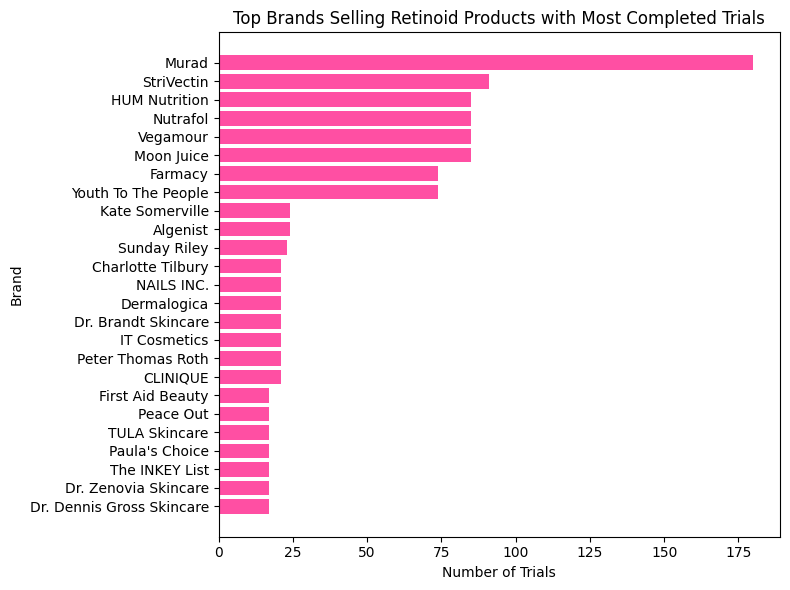

In [58]:
# Build bar chart showing top 25 brands using most backed up by research retinoid containing products
plot_top_brands_barh(
    df_brand_total,
    'total_completed',
    'Top Brands Selling Retinoid Products with Most Completed Trials',
    'Number of Trials',
    '#ff4fa3'
)

The results suggest that the top brands choosing more science backed retinoid containing products (or using more diverse group or retinoids) include `Murad` as absolute winner, followed by `StriVectin`. One way to see if the current results are heavily affected not just by the choice of retinoid but also by product variety is to build a plot showing number of different retinoids used by the brands.

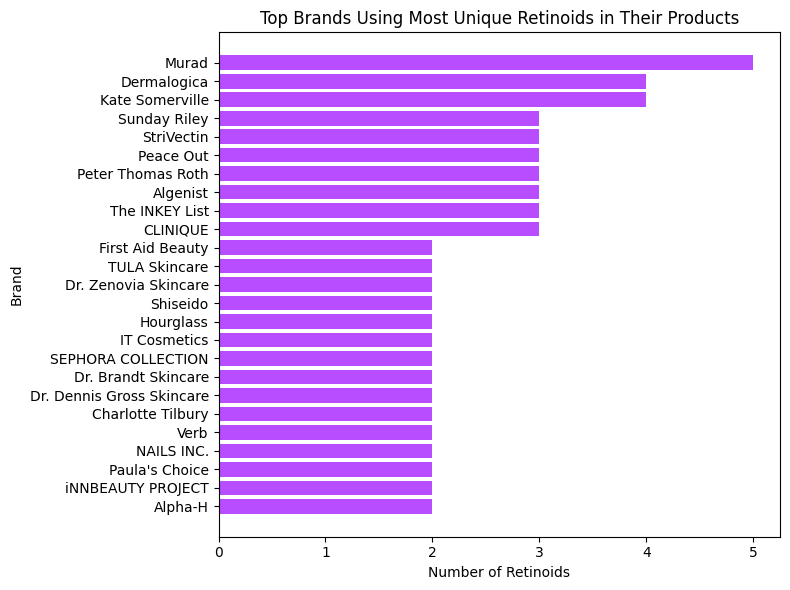

In [59]:
# Build bar chart showing top 25 brands using most kinds of retinoids in their products
plot_top_brands_barh(
    df_brand_total,
    'retinoid_count',
    'Top Brands Using Most Unique Retinoids in Their Products',
    'Number of Retinoids',
    '#b84dff'
)

Looks like `Murad` being the champion of the first bar plot is also leading in the current visualization. That could suggest that the brand uses a lot of different retinoids in their products, which in turn makes them a leader in using most research backed ingredients. Among other leaders of the current plot are `Dermalogica` and `Kate Somerville`. Their position in the previous plot is not as high, suggesting that their strategy is likely in using more innovative retinoids, that do not yet have robust research.

Another interesting question could be whether consumer interests lie in "tried-and-true" area or more innovative and experimental. For that let's look at how brands (and their retinoid products) are rated

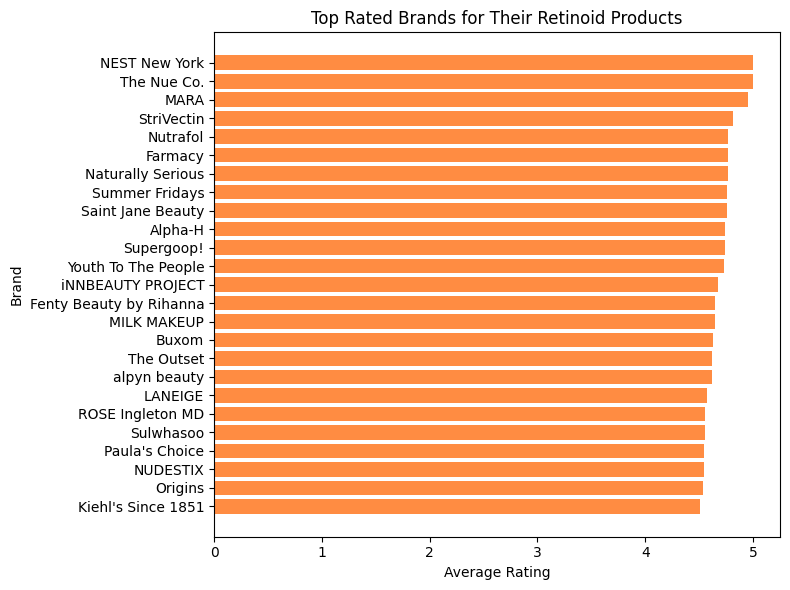

In [60]:
plot_top_brands_barh(
    df_brand_total,
    'total_rating',
    'Top Rated Brands for Their Retinoid Products',
    'Average Rating',
    '#ff8c42'
)

The plot demonstrates that retinol product ratings do not seem to depend too much on the retinol type or variety. This is not unexpected as many retinoids are capable of yielding great results when used in skincare. At this point it seems, that `StriVectin` has demonstrated that they use a good variety of well-studied retinoids in their products while maintaining high ratings for their retinoid products. This could be due to several factors, like quality of formulations, availability in stores, good marketing or long historic presence on the market.

While we're unable at this point to answer all of these questions, one can still be addressed.

Check if price per ounce of a retinoid containing product could also drive the ratings.

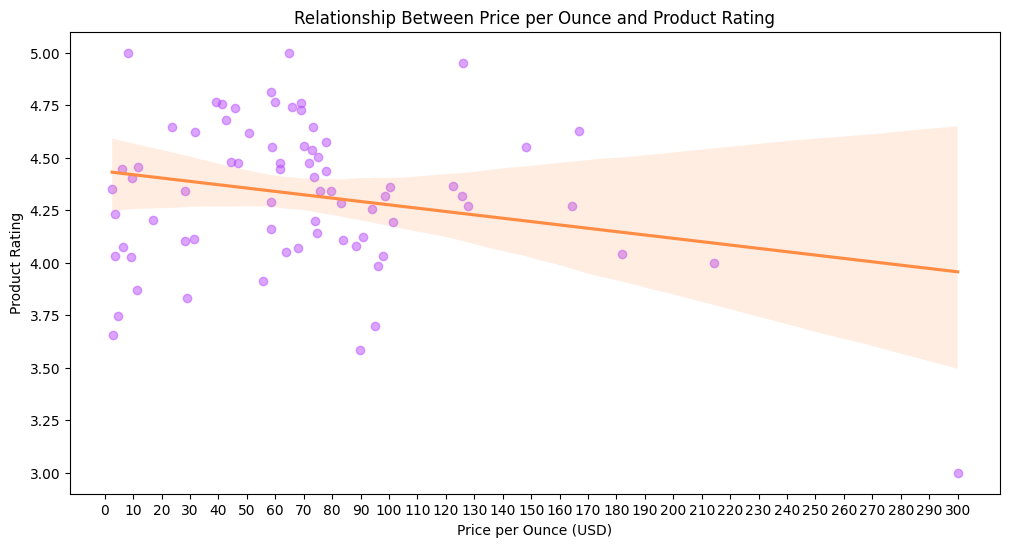

In [61]:
# Build a scatter plot for price/rating relationship investigation
top_price_rating = df_brand_total[['total_price_per_oz', 'total_rating']].dropna()

plt.figure(figsize=(12, 6))
sns.regplot(
    data=top_price_rating,
    x='total_price_per_oz',
    y='total_rating',
    scatter_kws={'color': '#b84dff', 'alpha': 0.5},
    line_kws={'color': '#ff8c42'}
)
plt.title('Relationship Between Price per Ounce and Product Rating')
plt.xlabel('Price per Ounce (USD)')
plt.ylabel('Product Rating')

x_max = top_price_rating['total_price_per_oz'].max()
plt.xticks(np.arange(0, x_max + 5, 10));

The scatter plot demonstrates weak to moderate negative direction, meaning that with the product price per ounce increase, the rating may go down. But because the correlation is not very strong and not very obvious, one way to test that would be to calculate the `correlation coefficient`. The results should be interpreted as follows: `[0.7<=|r|<1.0]` - strong, positive, `[0.3<=|r|<0.7]` - moderate, positive,  `[0.0 <=|r|<0.3]` - weak, positive, `-0.7<=|r|<-1.0]` - strong, negative, `[-0.3<=|r|<-0.7]` - moderate, negative,  `[0.0 <= |r| <-0.3]` - weak, negative.

In [62]:
# Remove missing values
df_brand_total_r = df_brand_total[['total_price_per_oz', 'total_rating']].dropna()
# Calculate r
r = df_brand_total_r['total_price_per_oz'].corr(df_brand_total_r['total_rating'])
print(r)

-0.2348404163577007


The `correlation coefficient` suggests that the scatter plot has `weak negative direction`. This is not unusual as retinoids are not cheap ingredients. For that reason, chances are that very cheap products containing retinols may not have the effective strength, which could negatively affect the rating. However, it is still possible to conclude that there seems to be two prominent price groups, with cheaper retinol products having range of ratings at or under `4.5` at the price point under `$20`, while the bulk retinol containing products fall into the category between `$50` and `$80`, showing a range of ratings, most of which are about `4.25`.

### 4.1: Reflection

[back to the ToC](#Table-of-Contents)

Current research while extensive, could benefit from some more in-depth analysis using several more sources of data. For example, such resources as `openFDA API`, with some more specific data on individual products, or `PubMed` - a scientific library with peer-reviewed clinical evaluations of ingredients, or `Journal of Cosmetic Dermatology`, available through the `Wiley Online Library`, could help cover the gaps regarding missing and newer forms of OTC retinoids, while some other sources like `GoodRx APIs` could add some information on pricing and sales of prescription retinoids.
Another alley for improvement could be analysing the columns with products `ingredients`. It is a common knowledge that ingredients located higher on the list are of higher concentrations. Thus, checking whether products with higher retinoid concentrations cost more or are getting higher rating could be interesting question for further research.

The manually sourced data from `ClinicalTrials.gov` dataset is also not exhastive. There is a `AACT` database (Aggregate Analysis of ClinicalTrials.gov) that contains a lot more research results data about clinical trials. Its [schema](https://aact.ctti-clinicaltrials.org/schema) offers many related tables of data and could potentially present a good field for further researching exsiting clinical trials.